In [78]:
import pandas as P

In [79]:
D = P.read_csv ("EVP Data.csv")

In [80]:
print(D.columns)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')


In [81]:
print(D.shape)

(280833, 16)


In [82]:
print(D.dtypes)

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object


In [83]:
DUP = D.duplicated ().sum ()
print(DUP)

0


In [84]:
NV = D.isnull ().sum ()
print(NV)

VIN (1-10)                                             0
County                                                12
City                                                  12
State                                                  0
Postal Code                                           12
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        12
Legislative District                                 703
DOL Vehicle ID                                         0
Vehicle Location                                      20
Electric Utility                                      12
2020 Census Tract                                     12
dtype: int64


In [85]:
NUM_C = D.select_dtypes(include = ["int64" , "float64"]).columns
C_C = D.select_dtypes (include = ["object"]).columns
print(NUM_C)
print("\n")
print(C_C)

Index(['Postal Code', 'Model Year', 'Electric Range', 'Legislative District',
       'DOL Vehicle ID', '2020 Census Tract'],
      dtype='object')


Index(['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location',
       'Electric Utility'],
      dtype='object')


In [86]:
D[NUM_C] = D[NUM_C].fillna(D[NUM_C].mean ())
D[C_C] = D[C_C].fillna(D[C_C].mode ())
print(D[NUM_C])
print("\n")
print(D[C_C])

        Postal Code  Model Year  Electric Range  Legislative District  \
0           98034.0        2013            75.0                   1.0   
1           98110.0        2020           308.0                  23.0   
2           98144.0        2018           215.0                  37.0   
3           98597.0        2024             0.0                   2.0   
4           98030.0        2020           291.0                  47.0   
...             ...         ...             ...                   ...   
280828      98264.0        2025             0.0                  42.0   
280829      98294.0        2022             0.0                  39.0   
280830      98258.0        2026             0.0                  39.0   
280831      98275.0        2026             0.0                  21.0   
280832      98270.0        2023             0.0                  44.0   

        DOL Vehicle ID  2020 Census Tract  
0            154635729       5.303302e+10  
1            107518645       5.3035

In [87]:
NV_2 = D.isnull ().sum ()
print(NV_2)

VIN (1-10)                                            0
County                                               12
City                                                 12
State                                                 0
Postal Code                                           0
Model Year                                            0
Make                                                  0
Model                                                 0
Electric Vehicle Type                                 0
Clean Alternative Fuel Vehicle (CAFV) Eligibility     0
Electric Range                                        0
Legislative District                                  0
DOL Vehicle ID                                        0
Vehicle Location                                     20
Electric Utility                                     12
2020 Census Tract                                     0
dtype: int64


In [88]:
from sklearn.preprocessing import LabelEncoder

In [89]:
print(D.dtypes)

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object


In [90]:
SR = D.rename (columns = {"County" : "Country"} , inplace = True)
print(SR)

None


In [91]:
print(D.columns)

Index(['VIN (1-10)', 'Country', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')


In [92]:
print(D.dtypes)

VIN (1-10)                                            object
Country                                               object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object


In [93]:
LE = LabelEncoder ()

In [94]:
D["VIN (1-10)"] = LE.fit_transform(D["VIN (1-10)"])
D["Country"] = LE.fit_transform(D["Country"])
D["City"] = LE.fit_transform(D["City"])
D["State"] = LE.fit_transform(D["State"])
D["Make"] = LE.fit_transform(D["Make"])
D["Model"] = LE.fit_transform(D["Model"])
D["Electric Vehicle Type"] = LE.fit_transform(D["Electric Vehicle Type"])
D["Clean Alternative Fuel Vehicle (CAFV) Eligibility"] = LE.fit_transform(D["Clean Alternative Fuel Vehicle (CAFV) Eligibility"])
D["Vehicle Location"] = LE.fit_transform(D["Vehicle Location"])
D["Electric Utility"] = LE.fit_transform(D["Electric Utility"])

In [95]:
print(D.dtypes)

VIN (1-10)                                             int64
Country                                                int64
City                                                   int64
State                                                  int64
Postal Code                                          float64
Model Year                                             int64
Make                                                   int64
Model                                                  int64
Electric Vehicle Type                                  int64
Clean Alternative Fuel Vehicle (CAFV) Eligibility      int64
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                       int64
Electric Utility                                       int64
2020 Census Tract                                    float64
dtype: object


In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
SC = StandardScaler ()

In [98]:
Scaling = SC.fit_transform (D)
print(Scaling)

[[-1.22841085 -0.41731191 -0.40705248 ... -0.21652073  0.67589979
   0.03784803]
 [-0.32651025 -0.3804137  -1.72356574 ...  0.88347523  0.6250311
   0.03909814]
 [-0.33710564 -0.41731191  0.82020565 ...  0.10231868 -0.18886783
   0.03784005]
 ...
 [ 0.51982914  1.31690404 -0.34754905 ... -0.59912802  0.6250311
   0.05478735]
 [ 0.16061944  1.31690404  0.10616456 ... -0.00927512  0.6250311
   0.05478039]
 [ 0.22057387  1.31690404 -0.08722157 ... -0.41579536  0.6250311
   0.05478686]]


In [99]:
import matplotlib.pyplot as PLOT
import seaborn as SEA

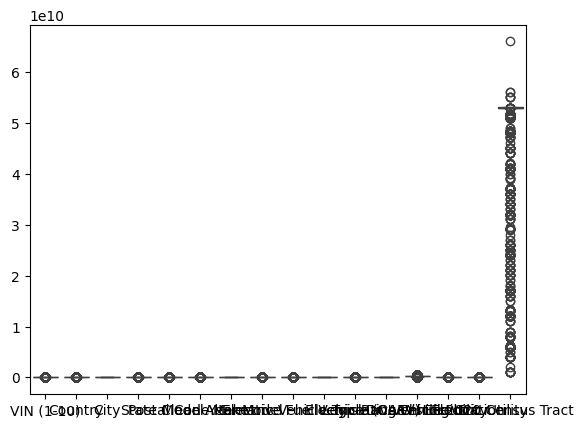

In [100]:
SEA.boxplot (D)
PLOT.show ()

In [101]:
print(D.shape)

(280833, 16)


In [102]:
Q1 = D.quantile (0.25)
Q2 = D.quantile (0.75)
IQR = Q2 - Q1
L = Q1 - (IQR * 1.5)
U = Q2 + (IQR * 1.5)
print(Q1)
print(Q2)
print(IQR)
print(L)
print(U)
print("\n")
RO = D[((D >= L).all(axis = 1)) & ((D <= U).all(axis = 1))]
print(RO)

VIN (1-10)                                           5.022000e+03
Country                                              1.160000e+02
City                                                 2.650000e+02
State                                                4.900000e+01
Postal Code                                          9.805200e+04
Model Year                                           2.021000e+03
Make                                                 1.700000e+01
Model                                                9.500000e+01
Electric Vehicle Type                                0.000000e+00
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0.000000e+00
Electric Range                                       0.000000e+00
Legislative District                                 1.700000e+01
DOL Vehicle ID                                       2.240730e+08
Vehicle Location                                     4.470000e+02
Electric Utility                                     5.800000e+01
2020 Censu

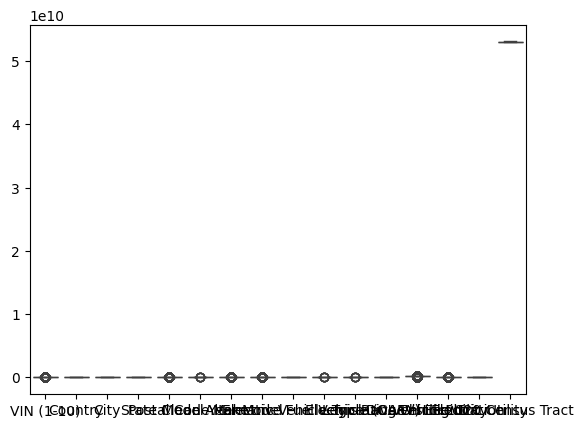

In [103]:
SEA.boxplot (RO)
PLOT.show ()

In [104]:
SF = D.to_csv ("EVP Dataset Clean.csv")
print(D.shape)

(280833, 16)
